# Phase 1: Document Vectorization (LangChain Edition)

This notebook demonstrates the first stage of the RAG pipeline using LangChain abstractions: **Ingestion and Storage**.

We will cover:
1. **Extraction**: Reading text from a PDF into LangChain `Document` objects.
2. **Chunking**: Splitting `Document`s into manageable segments.
3. **Embedding**: Converting text into semantic vectors using `HuggingFaceEmbeddings`.
4. **Indexing**: Saving segments to a local ChromaDB store via LangChain.

In [21]:
import os
import glob
from langchain_community.document_loaders import PDFPlumberLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma

print("LangChain modules loaded successfully.")

LangChain modules loaded successfully.


## 1. Text Extraction

We'll use LangChain's `PDFPlumberLoader` to extract raw text from all PDFs found in `data/raw/`.

> **Note**: We use specific `x_tolerance` settings to handle complex academic layouts and ensure words don't get stuck together.

In [22]:
pdf_dir = "../data/raw/"
pdf_files = glob.glob(os.path.join(pdf_dir, "*.pdf"))

if not pdf_files:
    print(f"Error: No PDF files found in {pdf_dir}. Please add some PDFs to process.")
else:
    print(f"Found {len(pdf_files)} PDF(s) to process.")
    documents = []
    for pdf_path in pdf_files:
        try:
            print(f"Extracting: {os.path.basename(pdf_path)}...")
            # Explicitly use PDFPlumberLoader
            loader = PDFPlumberLoader(
                pdf_path, 
                text_kwargs={"x_tolerance": 1.5, "y_tolerance": 1.5}
            )
            docs = loader.load()
            
            # Add metadata indicating the source file
            for doc in docs:
                 doc.metadata['source'] = os.path.basename(pdf_path)
            documents.extend(docs)
        except Exception as e:
            print(f"  -> Failed to extract {os.path.basename(pdf_path)}: {e}")
            
    print(f"\nTotal: Extracted {len(documents)} pages from {len(pdf_files)} PDF(s).")
    if documents:
        print("\n--- Sample Text (First 1000 chars of first extracted page) ---")
        print(documents[0].page_content[:1000])


Found 10 PDF(s) to process.
Extracting: 2604.19724v1.pdf...
Extracting: 2604.19728v1.pdf...
Extracting: 2604.19729v1.pdf...
Extracting: 2604.19730v1.pdf...
Extracting: 2604.19734v1.pdf...
Extracting: 2604.19736v1.pdf...
Extracting: 2604.19737v1.pdf...
Extracting: 2604.19738v1.pdf...
Extracting: 2604.19740v1.pdf...
Extracting: 2604.19741v1.pdf...

Total: Extracted 330 pages from 10 PDF(s).

--- Sample Text (First 1000 chars of first extracted page) ---
Benign Overfitting in Adversarial Training for Vision Transformers
Jiaming Zhang 1 2 Meng Ding 3 Shaopeng Fu 1 Jingfeng Zhang 4 Di Wang 1
Abstract
2013), can often cause significant performance degradation.
Despite the remarkable success of Vision Trans-
A widely studied defense mechanism against such vulner-
formers (ViTs) across a wide range of vision tasks,
abilities is adversarial training (Goodfellow et al., 2014;
recent studies have revealed that they remain vul-
2016), which augments the training process with adver-
nerable to adve

## 2. Text Chunking

Raw text is too long for LLMs to process efficiently. We split our LangChain `Document`s into smaller overlapping chunks.

In [23]:
chunk_size = 500
chunk_overlap = 100

# Explicitly define the Text Splitter
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=chunk_size,
    chunk_overlap=chunk_overlap,
    length_function=len,
    is_separator_regex=False,
)
chunks = text_splitter.split_documents(documents)
print(f"Split documents into {len(chunks)} chunks.")

if chunks:
    print("\n--- Chunk 1 ---")
    print(chunks[0].page_content)
    print("\n--- Chunk 2 ---")
    print(chunks[1].page_content)

Split documents into 2548 chunks.

--- Chunk 1 ---
Benign Overfitting in Adversarial Training for Vision Transformers
Jiaming Zhang 1 2 Meng Ding 3 Shaopeng Fu 1 Jingfeng Zhang 4 Di Wang 1
Abstract
2013), can often cause significant performance degradation.
Despite the remarkable success of Vision Trans-
A widely studied defense mechanism against such vulner-
formers (ViTs) across a wide range of vision tasks,
abilities is adversarial training (Goodfellow et al., 2014;
recent studies have revealed that they remain vul-

--- Chunk 2 ---
recent studies have revealed that they remain vul-
2016), which augments the training process with adver-
nerable to adversarial examples, much like Con-
sarially perturbed samples to improve model robustness.
volutional Neural Networks (CNNs). A common
While adversarial training has proven effective in enhanc-
empirical defense strategy is adversarial training,
ing model robustness, it is frequently accompanied by a
yet the theoretical underpinnings of 

## 3. Vector Storage (LangChain Chroma)

Now we convert these chunks into embeddings using a local `HuggingFaceEmbeddings` model and save them to our local Chroma vector store via LangChain.

In [24]:
from src.core.config import settings
# Initialize Embeddings Model
embedding_function = HuggingFaceEmbeddings(model_name=settings.EMBEDDING_MODEL_NAME)

# Initialize ChromaDB
vectorstore = Chroma(
    collection_name=settings.COLLECTION_NAME,
    embedding_function=embedding_function,
    persist_directory=settings.CHROMA_DB_PATH
)

# Add chunks to store
vectorstore.add_documents(documents=chunks)

print(f"Successfully indexed {len(vectorstore.get()['ids'])} items in the vector store.")

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event CollectionGetEvent: capture() takes 1 positional argument but 3 were given


Successfully indexed 6390 items in the vector store.


## 4. Verification

Let's check if we can retrieve something back.

In [25]:
results = vectorstore.similarity_search("What is smart contract fuzzing?", k=2)
for i, doc in enumerate(results):
    print(f"\n--- Result {i+1} ---")
    print(doc.page_content[:200] + "...")


Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given



--- Result 1 ---
vulnerable transaction sequences in smart contracts with reinforcement
Network. [Online]. Available: https://ieeexplore.ieee.org/abstract/docum
learning-guided fuzzing,” in Proceedings of the 37th IEE...

--- Result 2 ---
vulnerable transaction sequences in smart contracts with reinforcement
Network. [Online]. Available: https://ieeexplore.ieee.org/abstract/docum
learning-guided fuzzing,” in Proceedings of the 37th IEE...


## 5. Visualizing Embeddings (t-SNE)

To get an intuition for what embeddings look like, we can reduce their high-dimensional vectors down to 2 dimensions using t-SNE (t-Distributed Stochastic Neighbor Embedding) and plot them.

Applying t-SNE to 6390 embeddings...


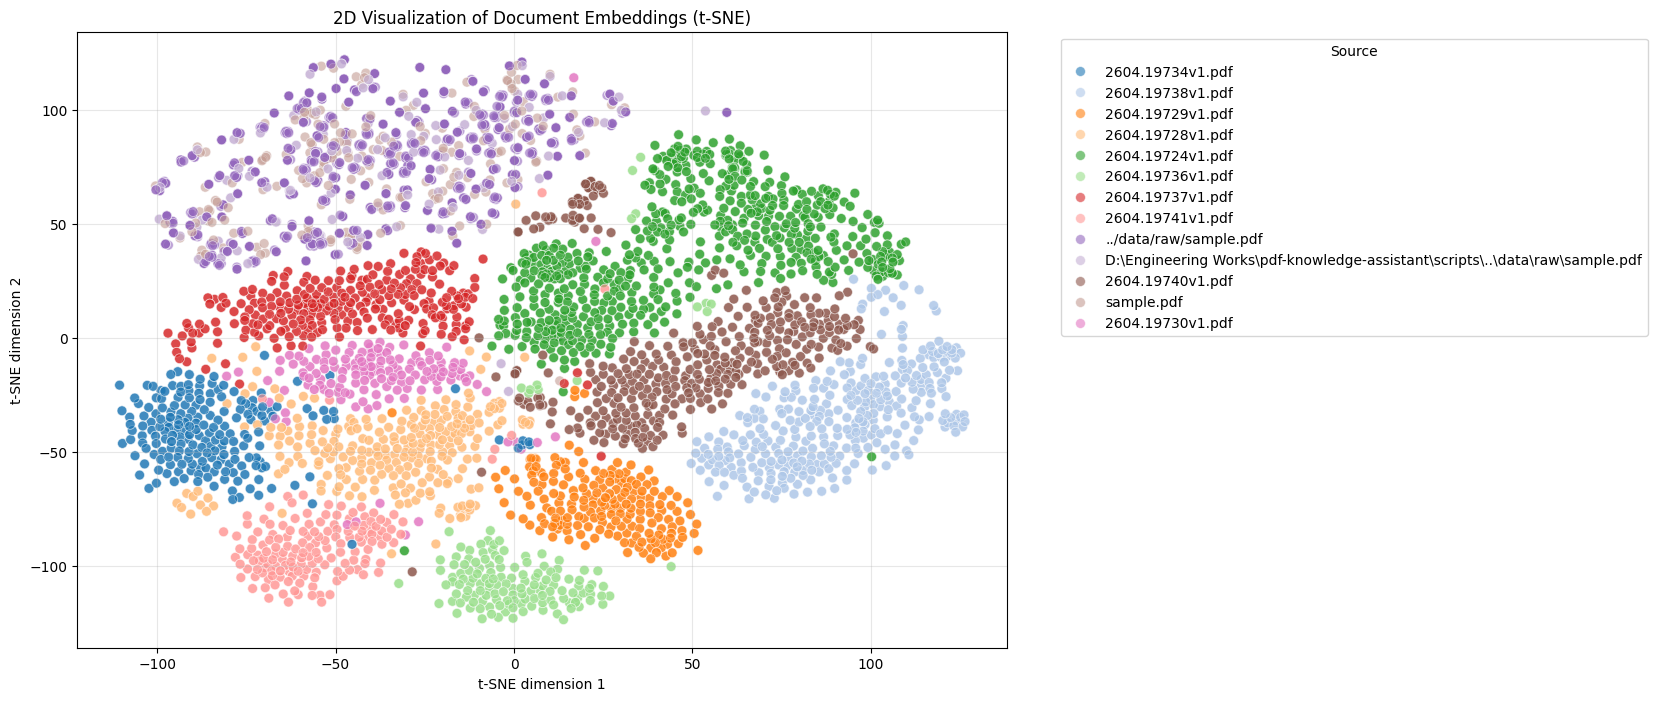

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.manifold import TSNE

# 1. Extract embeddings and metadata
data = vectorstore.get(include=['embeddings', 'metadatas'])
embeddings = np.array(data['embeddings'])
sources = [m.get('source', 'unknown') for m in data['metadatas']]

if len(embeddings) > 0:
    print(f"Applying t-SNE to {len(embeddings)} embeddings...")
    
    # 2. Run t-SNE
    tsne = TSNE(n_components=2, perplexity=30, init='pca', random_state=42)
    embeddings_2d = tsne.fit_transform(embeddings)

    # 3. Plot
    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        x=embeddings_2d[:, 0], 
        y=embeddings_2d[:, 1], 
        hue=sources, 
        palette='tab20', 
        alpha=0.6,
        s=50,
        edgecolor='w',
        legend='full'
    )
    
    plt.title("2D Visualization of Document Embeddings (t-SNE)")
    plt.xlabel("t-SNE dimension 1")
    plt.ylabel("t-SNE dimension 2")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Source')
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No embeddings found to visualize.")